# Hourly Delay Profile

Shows the local hours when buses are most late.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "hourly_delay_profile",
    PROJECT_ROOT / "analysis" / "hourly-delay-profile.py",
)
hourly = importlib.util.module_from_spec(spec)
spec.loader.exec_module(hourly)

DB = PROJECT_ROOT / "data" / "foli.db"
TIMEZONE = "Europe/Helsinki"
LINE_REF = None
MIN_OBSERVATIONS = 1
LIMIT = 24

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    line_ref = LINE_REF

df = hourly.load_observations(Args)
profile = hourly.build_profile(df, TIMEZONE, MIN_OBSERVATIONS, LIMIT)
profile

,hour_local,obs_count,avg_delay_min,median_delay_min,pct_late,pct_over_3_min_late
16,16:00,88387,0.99,0.12,52.01,16.39
15,15:00,92701,0.89,0.20,53.51,16.68
13,13:00,69637,0.68,0.00,49.04,11.98
14,14:00,92501,0.67,0.00,48.19,13.14
3,03:00,57,0.63,0.00,17.54,10.53
12,12:00,56439,0.36,0.00,44.25,10.07
17,17:00,82087,-0.01,0.00,40.87,8.58
20,20:00,56408,-0.03,0.00,40.97,7.89
22,22:00,45801,-0.07,0.00,35.07,5.62
18,18:00,72742,-0.09,0.00,41.02,8.51


Delay has positive and negative values. Positive values mean that bus is is late. Negative value means bus is early.

Text(0, 0.5, 'Average delay, minutes')

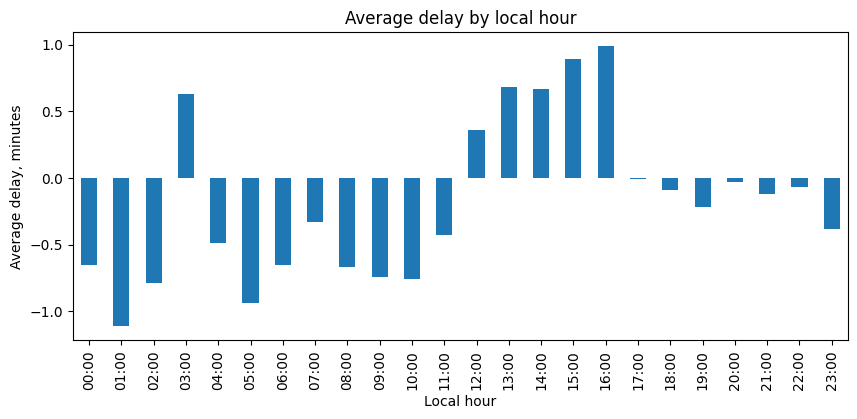

In [3]:
ax = profile.sort_values("hour_local").plot.bar(
    x="hour_local",
    y="avg_delay_min",
    legend=False,
    figsize=(10, 4),
    title="Average delay by local hour",
)
ax.set_xlabel("Local hour")
ax.set_ylabel("Average delay, minutes")